#  Credit Card Fraud Detection using Machine Learning

##  Project Overview

Credit card fraud detection is one of the most important real-world applications of machine learning. The challenge lies in identifying fraudulent transactions from an extremely imbalanced dataset where fraudulent transactions represent less than **0.2%** of all observations.

In this project, multiple machine learning models are trained and evaluated to detect fraudulent transactions. Special emphasis is placed on handling class imbalance and selecting evaluation metrics that better reflect fraud detection performance than accuracy alone.

---

#  Load Dataset

The dataset contains anonymized credit card transactions made by European cardholders.

### Dataset Information

- **Total Transactions:** 284,807
- **Fraudulent Transactions:** 492
- **Features:** 30 numerical features + Target
- **Target Variable:** Class
    - 0 → Legitimate Transaction
    - 1 → Fraudulent Transaction

Most features are principal components obtained using **PCA**, while **Time** and **Amount** remain unchanged.

In [68]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.shape

(284807, 31)

# Initial Data Exploration

Before building machine learning models, it is essential to understand the structure of the dataset.

The following inspection includes:

- Shape of dataset
- Feature data types
- Missing values
- Statistical summary

In [69]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


#  Data Cleaning

Data quality is verified before model training.

Checks performed:

- Missing Values
- Duplicate Transactions
- Class Distribution

In [72]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [73]:
print("Duplicated Rows:",df.duplicated().sum())

Duplicated Rows: 1081


In [74]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [75]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

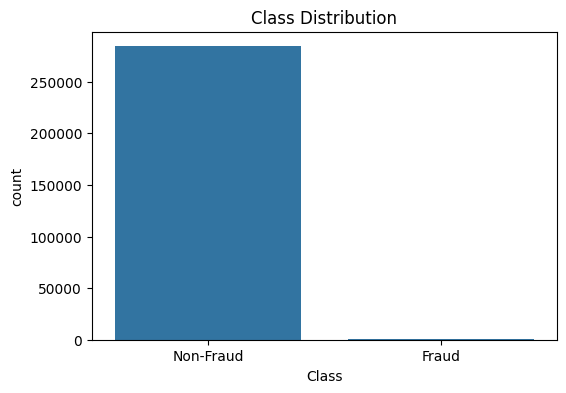

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Class Distribution")

plt.xticks([0,1], ["Non-Fraud", "Fraud"])

plt.show()

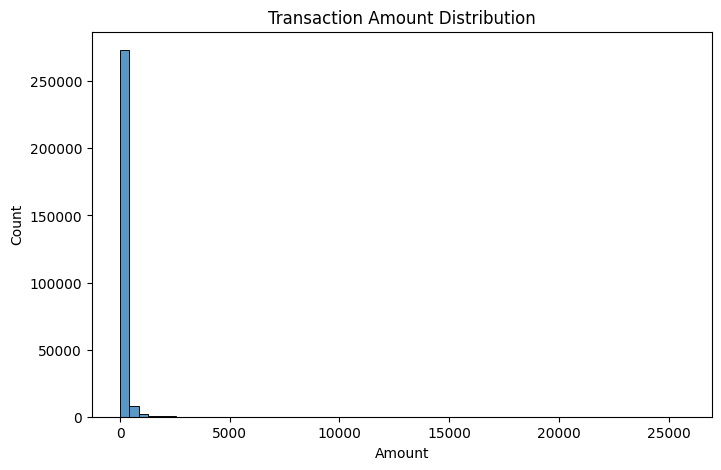

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Amount"],
    bins=60
)

plt.title("Transaction Amount Distribution")

plt.show()

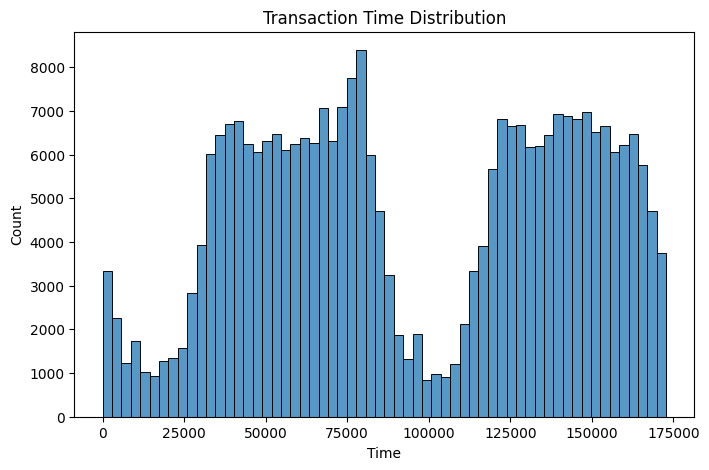

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Time"],
    bins=60
)

plt.title("Transaction Time Distribution")

plt.show()

In [79]:
fraud_percentage = df["Class"].mean() * 100

print(f"Fraud Transactions: {fraud_percentage:.4f}%")

Fraud Transactions: 0.1727%


#  Duplicate Removal

Duplicate transactions do not provide additional information and may bias the learning process.

Removing duplicate rows helps improve data quality while slightly reducing the dataset size.

In [80]:
print("Original Shape:",df.shape)
df = df.drop_duplicates()
print("New Shape:",df.shape)

Original Shape: (284807, 31)
New Shape: (283726, 31)


In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
X = df.drop("Class",axis=1)
y = df["Class"]

#  Train-Test Split

The dataset is divided into training and testing sets using **stratified sampling**.

Stratification preserves the fraud ratio in both datasets, ensuring a fair evaluation.

In [83]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape,X_test.shape

((226980, 30), (56746, 30))

In [84]:
print(y_train.value_counts())

print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


In [85]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


#  Logistic Regression

Logistic Regression serves as the baseline model for binary classification.

Although simple, it provides a strong benchmark and allows comparison with more sophisticated ensemble models.

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        random_state=42,
        max_iter=1000
    )
)

log_reg.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [87]:
log_reg_pred = log_reg.predict(X_test)

#  Class Imbalance Analysis

Credit card fraud datasets are **highly imbalanced**.

Fraudulent transactions account for only a tiny fraction of the dataset.

Because of this imbalance, **accuracy alone is not an appropriate evaluation metric**.

Instead, metrics such as:

- Precision
- Recall
- F1 Score

are used throughout this project.

In [88]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
log_accuracy = accuracy_score(y_test,log_reg_pred)
log_precision = precision_score(y_test,log_reg_pred)
log_recall = recall_score(y_test,log_reg_pred)
log_f1 = f1_score(y_test,log_reg_pred)

In [89]:
print("Accuracy:",log_accuracy)
print("Precision:",log_precision)
print("Recall:",log_recall)
print("f1_score:",log_f1)

Accuracy: 0.9991188806259472
Precision: 0.8461538461538461
Recall: 0.5789473684210527
f1_score: 0.6875


In [90]:
from sklearn.metrics import classification_report
print(classification_report(y_test, log_reg_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



#  Confusion Matrix

The confusion matrix provides a detailed breakdown of predictions.

For fraud detection, minimizing **False Negatives** is especially important because undetected fraudulent transactions may lead to financial losses.

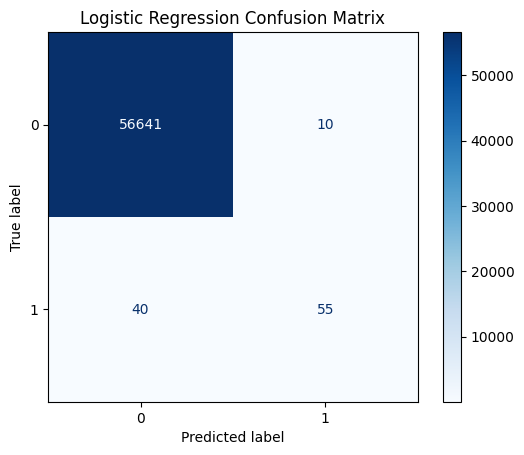

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_reg_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [92]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [93]:
tree_clf_pred = tree_clf.predict(X_test)

In [94]:
dt_accuracy = accuracy_score(y_test, tree_clf_pred)
dt_precision = precision_score(y_test, tree_clf_pred)
dt_recall = recall_score(y_test, tree_clf_pred)
dt_f1 = f1_score(y_test, tree_clf_pred)

In [95]:
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)

Accuracy: 0.999048391076023
Precision: 0.7204301075268817
Recall: 0.7052631578947368
F1 Score: 0.7127659574468085


#  Classification Report

The classification report summarizes:

- Precision
- Recall
- F1 Score

These metrics provide a more reliable evaluation than accuracy for highly imbalanced datasets.

In [96]:
print(classification_report(y_test, tree_clf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746



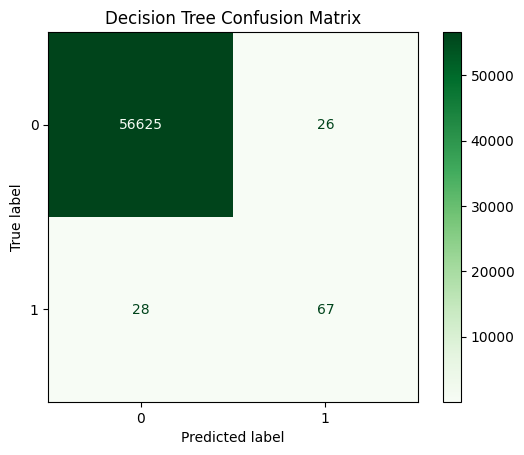

In [97]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_clf_pred,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

#  Cross Validation

Cross Validation evaluates the model on multiple train-validation splits to estimate its generalization ability.

Reporting both the **mean** and **standard deviation** helps assess model stability.

In [99]:
from sklearn.model_selection import cross_val_score

log_cv = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print(log_cv)

log_cv_mean = log_cv.mean()

print("Mean F1:", log_cv_mean)

log_cv_std = log_cv.std()

print("Std:", log_cv_std)

[0.67226891 0.69291339 0.71111111 0.69767442 0.77697842]
Mean F1: 0.7101892480743492
Std: 0.03565016563872361


In [100]:
dt_cv = cross_val_score(
    tree_clf,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print(dt_cv)

dt_cv_mean = dt_cv.mean()

print("Mean F1:", )

dt_cv_std = dt_cv.std()
print("Std:", dt_cv_std)

[0.73469388 0.69014085 0.76433121 0.72727273 0.81761006]
Mean F1:
Std: 0.04256651332009528


#  Linear Support Vector Classifier (LinearSVC)

LinearSVC attempts to find the optimal hyperplane that maximizes the margin between fraudulent and legitimate transactions.

Support Vector Machines are particularly effective in high-dimensional feature spaces.

In [101]:
from sklearn.svm import LinearSVC
linear_svc = make_pipeline(
    StandardScaler(),
    LinearSVC(
        random_state=42,
        max_iter=5000
    )
)
linear_svc.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(max_iter=5000, random_state=42))])

In [102]:
linear_pred = linear_svc.predict(X_test)

In [103]:
svc_accuracy = accuracy_score(y_test, linear_pred)
svc_precision = precision_score(y_test, linear_pred)
svc_recall = recall_score(y_test, linear_pred)
svc_f1 = f1_score(y_test, linear_pred)

In [104]:
print("Accuracy:", svc_accuracy)
print("Precision:", svc_precision)
print("Recall:", svc_recall)
print("F1 Score:", svc_f1)

Accuracy: 0.9991188806259472
Precision: 0.8688524590163934
Recall: 0.5578947368421052
F1 Score: 0.6794871794871795


In [105]:
print(classification_report(y_test, linear_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.56      0.68        95

    accuracy                           1.00     56746
   macro avg       0.93      0.78      0.84     56746
weighted avg       1.00      1.00      1.00     56746



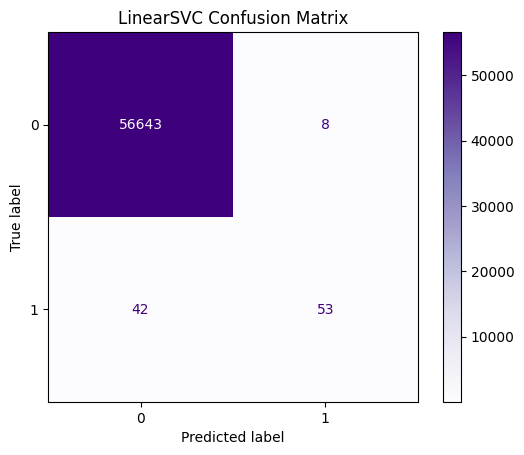

In [106]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    linear_pred,
    cmap="Purples"
)

plt.title("LinearSVC Confusion Matrix")

plt.show()

In [107]:
svc_cv = cross_val_score(
    linear_svc,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print(svc_cv)

svc_cv_mean = svc_cv.mean()
print("Mean F1:", svc_cv_mean)

svc_cv_std = svc_cv.std()
print("Std:", svc_cv_std)

[0.65       0.69918699 0.6875     0.703125   0.75384615]
Mean F1: 0.6987316291432145
Std: 0.03334078903712847


#  Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees using bagging.

Advantages:

- Handles nonlinear relationships
- Robust against overfitting
- Naturally estimates feature importance

In [108]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

rf_clf.fit(X_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [109]:
rf_pred = rf_clf.predict(X_test)

In [110]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

In [111]:
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Accuracy: 0.9995065731505305
Precision: 0.971830985915493
Recall: 0.7263157894736842
F1 Score: 0.8313253012048193


In [112]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



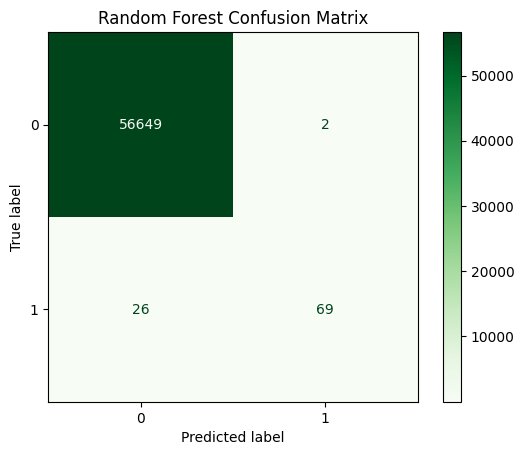

In [113]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [114]:
rf_cv = cross_val_score(
    rf_clf,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print(rf_cv)

rf_cv_mean = rf_cv.mean()
print("Mean F1:", rf_cv_mean)

rf_cv_std = rf_cv.std()
print("Std:", rf_cv_std)

[0.82706767 0.81203008 0.88111888 0.84892086 0.875     ]
Mean F1: 0.8488274977578272
Std: 0.026665642605952545


#  Model Comparison

Four machine learning algorithms were evaluated for fraud detection:

-  Decision Tree
-  Logistic Regression
-  Linear Support Vector Classifier (LinearSVC)
-  Random Forest Classifier

Since the dataset is highly imbalanced, **Accuracy alone is insufficient**. The primary evaluation metric is the **F1 Score**, supported by Precision, Recall, and Cross Validation performance.

The table below summarizes the performance of all trained models.

In [115]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "Linear SVC",
        "Random Forest"
    ],

    "Accuracy": [
        dt_accuracy,
        log_accuracy,
        svc_accuracy,
        rf_accuracy
    ],

    "Precision": [
        dt_precision,
        log_precision,
        svc_precision,
        rf_precision
    ],

    "Recall": [
        dt_recall,
        log_recall,
        svc_recall,
        rf_recall
    ],

    "F1 Score": [
        dt_f1,
        log_f1,
        svc_f1,
        rf_f1
    ],

    "CV Mean F1": [
        dt_cv_mean,
        log_cv_mean,
        svc_cv_mean,
        rf_cv_mean
    ],

    "CV Std": [
        dt_cv_std,
        log_cv_std,
        svc_cv_std,
        rf_cv_std
    ]
})

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "CV Mean F1": "{:.4f}",
    "CV Std": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean F1,CV Std
0,Random Forest,0.9995,0.9718,0.7263,0.8313,0.8488,0.0267
1,Decision Tree,0.9990,0.7204,0.7053,0.7128,0.7468,0.0426
2,Logistic Regression,0.9991,0.8462,0.5789,0.6875,0.7102,0.0357
3,Linear SVC,0.9991,0.8689,0.5579,0.6795,0.6987,0.0333


In [116]:
best_model = comparison_df.iloc[0]

print("=" * 50)
print(" Best Performing Model")
print("=" * 50)

print(f"Model         : {best_model['Model']}")
print(f"Accuracy      : {best_model['Accuracy']:.4f}")
print(f"Precision     : {best_model['Precision']:.4f}")
print(f"Recall        : {best_model['Recall']:.4f}")
print(f"F1 Score      : {best_model['F1 Score']:.4f}")
print(f"CV Mean F1    : {best_model['CV Mean F1']:.4f}")
print(f"CV Std        : {best_model['CV Std']:.4f}")

 Best Performing Model
Model         : Random Forest
Accuracy      : 0.9995
Precision     : 0.9718
Recall        : 0.7263
F1 Score      : 0.8313
CV Mean F1    : 0.8488
CV Std        : 0.0267


#  Conclusion

This project explored multiple supervised machine learning algorithms for detecting fraudulent credit card transactions on a highly imbalanced dataset.

## Model Comparison Summary

* **Random Forest** delivered the best overall performance, achieving the highest F1 Score (**83.13%**) and the strongest cross-validation performance (**84.88%**).
* **Decision Tree** performed reasonably well but was less stable and more prone to overfitting.
* **Logistic Regression** provided a strong baseline despite its simplicity.
* **Linear SVC** achieved excellent precision but missed a larger number of fraudulent transactions, resulting in lower recall.

## Final Model

 **Random Forest Classifier**

### Final Performance

* **Accuracy:** 99.95%
* **Precision:** 97.18%
* **Recall:** 72.63%
* **F1 Score:** 83.13%
* **Cross Validation Mean F1:** 84.88%

These results indicate that the Random Forest model provides the best trade-off between detecting fraudulent transactions and minimizing false positives.

---

## Key Learning Outcomes

Through this project, I gained practical experience with:

* Exploratory Data Analysis (EDA)
* Handling highly imbalanced datasets
* Data preprocessing and cleaning
* Decision Trees
* Logistic Regression
* Support Vector Machines (LinearSVC)
* Random Forests
* Hyperparameter Optimization using RandomizedSearchCV
* Cross Validation
* Model Evaluation using Precision, Recall, and F1 Score

---

## Future Improvements

Potential improvements include:

* XGBoost
* LightGBM
* CatBoost
* Stacking Classifier
* Threshold Optimization
* SHAP Explainability
* SMOTE for handling class imbalance
